# Evaluierung & Analyse: Temperature Ladder DPO Experiment (500 Tokens)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und vergleicht das **500-Token mBART-50 Modell** vor und nach dem **Direct Preference Optimization (DPO)** Training mit dem **Progressive Temperature Ladder Verfahren** auf dem ungesehenen **10kGNAD Alltagssprache-Korpus**.

### Untersuchte Modellkonfigurationen:
1. **SFT Baseline (500 Tokens):** Supervised Fine-Tuning Referenzmodell (`results/models/token_length_exp/sft_len500`)
2. **DPO Ladder (500 Tokens):** DPO Modell trainiert mit Temperature Ladder Präferenzpaaren (`results/models/temperature_ladder_500/dpo_w05_w05`)

### Kernfragen der Analyse:
- **Erhöht das Temperature Ladder DPO Training die Einfachheit ($R_{\text{style}}$), ohne Fakten zu verlieren ($R_{\text{sem}}$)?**
- **Wurden Wort- und Phrasenwiederholungen durch die Anti-Repetition-Constraints (`ngram=3`, `rep_penalty=1.35`) eliminiert?**
- **Wie verhält sich die Kompressionsrate und Satzstruktur im Vergleich zur SFT-Baseline?**

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import json
import glob
import random
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import ttest_rel, wilcoxon


# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

    if os.path.exists(candidate):
        os.chdir(candidate)

print("Arbeitsverzeichnis:", os.getcwd())
print(f"Nutze Device: {DEVICE}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150


Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


## 1. Temperature Ladder Evaluationsdaten laden

In [2]:
# ==============================================================================
# 2. ERGEBNIS-DATEN EINLESEN (Vorberechnet durch Sbatch / Evaluation-Script)
# ==============================================================================
DETAILS_CSV = "results/evaluation/temperature_ladder_500_details.csv"
if not os.path.exists(DETAILS_CSV):
    DETAILS_CSV = "../../../results/evaluation/temperature_ladder_500_details.csv"

df_all = pd.read_csv(DETAILS_CSV)
print(f"Ergebnisse erfolgreich geladen: {len(df_all)} Einträge aus {DETAILS_CSV}")
display(df_all.groupby("Model")[["style_score", "sbert_to_as", "composite_reward", "compression_ratio"]].mean())


In [5]:
# ==============================================================================
# 5. METRIKEN-VERGLEICHSTABELLE
# ==============================================================================
if len(results) > 0:
    summary_rows = []
    for name, df in results.items():
        summary_rows.append({
            "Modell": name,
            "Ø Style-Score (R_style)": f"{df['style_score'].mean():.4f} ± {df['style_score'].std():.4f}",
            "Ø SBERT zu AS (R_sem)": f"{df['sbert_to_as'].mean():.4f} ± {df['sbert_to_as'].std():.4f}",
            "Ø SBERT zu Gold LS": f"{df['sbert_to_ref'].mean():.4f} ± {df['sbert_to_ref'].std():.4f}",
            "Ø Composite Reward": f"{df['composite_reward'].mean():.4f} ± {df['composite_reward'].std():.4f}",
            "Ø Trigram-Diversität": f"{df['trigram_diversity'].mean()*100:.1f} %",
            "Ø Kompressionsrate": f"{df['compression_ratio'].mean():.3f}",
        })
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)


,Modell,Ø Style-Score (R_style),Ø SBERT zu AS (R_sem),Ø SBERT zu Gold LS,Ø Composite Reward,Ø Trigram-Diversität,Ø Kompressionsrate
0,SFT Baseline (500 Tokens),0.5628 ± 0.2170,0.7412 ± 0.1399,0.7247 ± 0.1275,0.7167 ± 0.1090,99.7 %,0.453
1,DPO Ladder (500 Tokens),0.9317 ± 0.0141,0.4412 ± 0.1524,0.4491 ± 0.1507,0.8261 ± 0.0395,99.1 %,0.262


In [6]:
# ==============================================================================
# 6. STATISTISCHE SIGNIFIKANZTESTS (PAIRED T-TEST & WILCOXON)
# ==============================================================================
if "SFT Baseline (500 Tokens)" in results and "DPO Ladder (500 Tokens)" in results:
    sft_df = results["SFT Baseline (500 Tokens)"]
    dpo_df = results["DPO Ladder (500 Tokens)"]
    
    metrics = ["style_score", "sbert_to_as", "sbert_to_ref", "composite_reward", "trigram_diversity"]
    sig_rows = []
    
    for m in metrics:
        t_stat, p_val_t = ttest_rel(dpo_df[m], sft_df[m])
        w_stat, p_val_w = wilcoxon(dpo_df[m], sft_df[m])
        delta = dpo_df[m].mean() - sft_df[m].mean()
        sig_rows.append({
            "Metrik": m,
            "SFT Mittelwert": f"{sft_df[m].mean():.4f}",
            "DPO Mittelwert": f"{dpo_df[m].mean():.4f}",
            "Δ Differenz": f"{delta:+.4f}",
            "p-Wert (Paired t-Test)": f"{p_val_t:.4e}",
            "Signifikant (p < 0.05)": "✅ Ja" if p_val_t < 0.05 else "❌ Nein",
        })
        
    df_sig = pd.DataFrame(sig_rows)
    display(df_sig)


,Metrik,SFT Mittelwert,DPO Mittelwert,Δ Differenz,p-Wert (Paired t-Test),Signifikant (p < 0.05)
0,style_score,0.5628,0.9317,+0.3689,1.9179e-12,✅ Ja
1,sbert_to_as,0.7412,0.4412,-0.3001,3.3000e-11,✅ Ja
2,sbert_to_ref,0.7247,0.4491,-0.2756,2.6730e-11,✅ Ja
3,composite_reward,0.7167,0.8261,+0.1094,7.6283e-07,✅ Ja
4,trigram_diversity,0.9971,0.9914,-0.0057,1.3332e-03,✅ Ja


## 2. Publikationsreife Visualisierungen (Einfachheit, Semantik & Textkürzung)

<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1610874/249100781.py:24: SyntaxWarning: invalid escape sequence '\c'
  axes[2].set_title("Composite Reward ($0.5 \cdot R_{style} + 0.5 \cdot R_{sem}$)", fontsize=13, fontweight="bold")


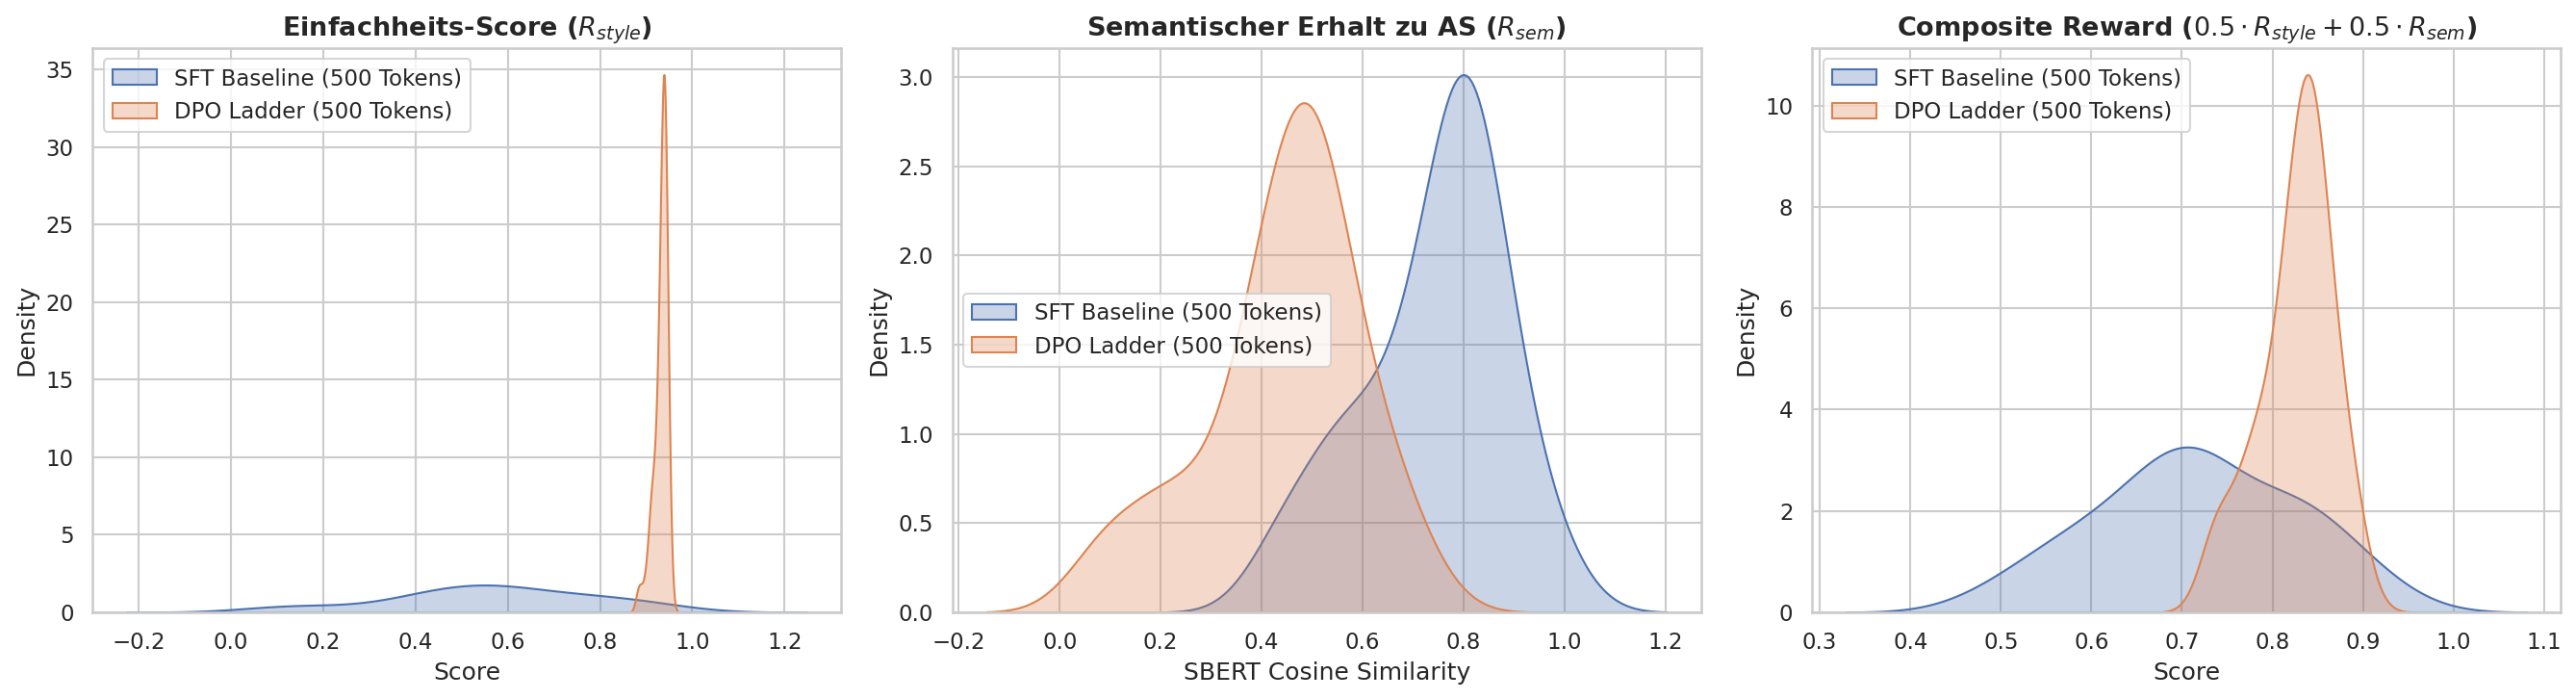

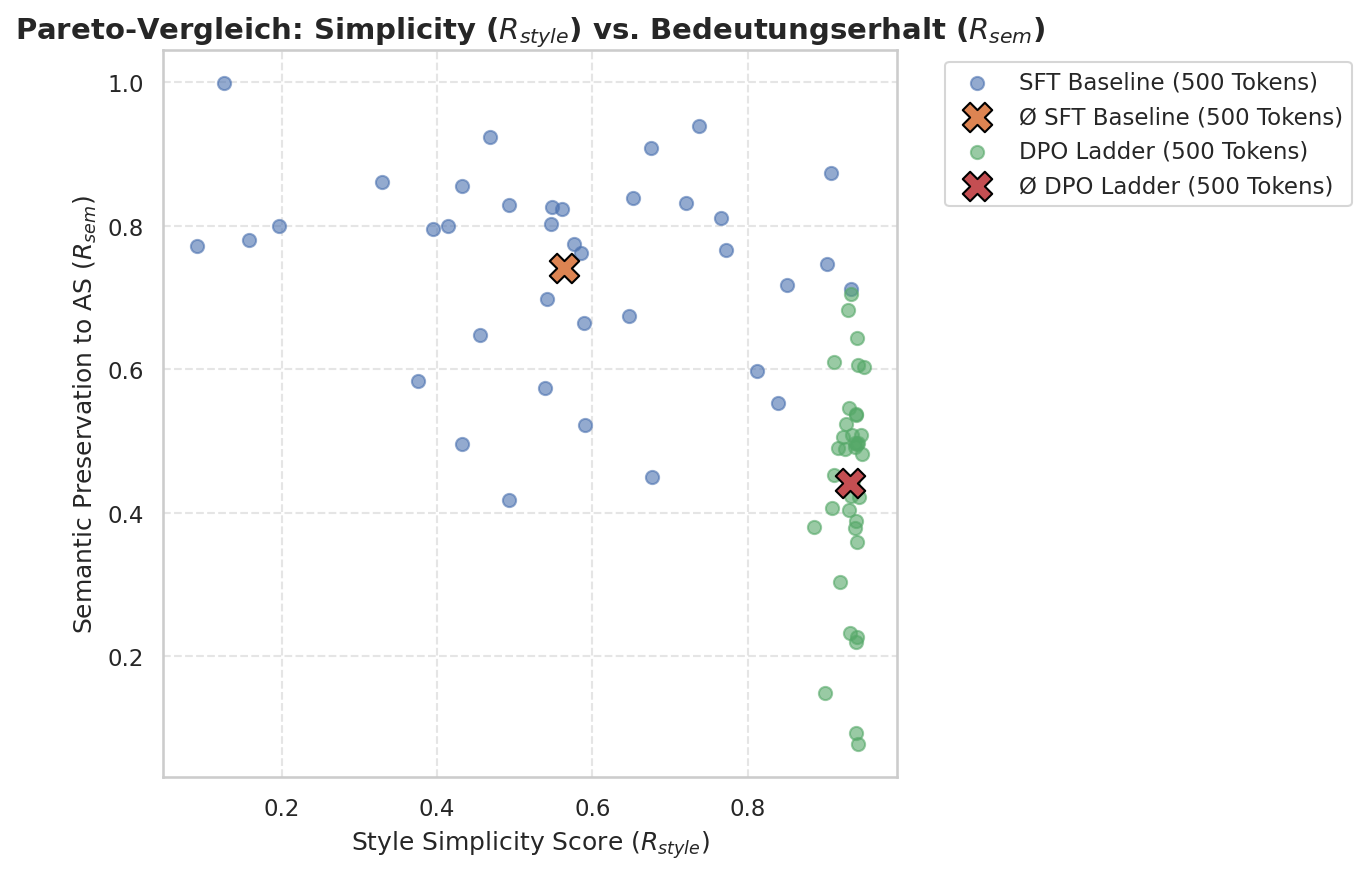

In [7]:
# ==============================================================================
# 7. VISUALISIERUNGEN (KDE-VERTEILUNGEN & PARETO-SCATTERPLOT)
# ==============================================================================
if len(results) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Style Score KDE
    for name, df in results.items():
        sns.kdeplot(df["style_score"], ax=axes[0], label=name, fill=True, alpha=0.3)
    axes[0].set_title("Einfachheits-Score ($R_{style}$)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Score")
    axes[0].legend()
    
    # 2. SBERT Semantik KDE
    for name, df in results.items():
        sns.kdeplot(df["sbert_to_as"], ax=axes[1], label=name, fill=True, alpha=0.3)
    axes[1].set_title("Semantischer Erhalt zu AS ($R_{sem}$)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("SBERT Cosine Similarity")
    axes[1].legend()
    
    # 3. Composite Reward KDE
    for name, df in results.items():
        sns.kdeplot(df["composite_reward"], ax=axes[2], label=name, fill=True, alpha=0.3)
    axes[2].set_title("Composite Reward ($0.5 \cdot R_{style} + 0.5 \cdot R_{sem}$)", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Score")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Pareto Plot
    plt.figure(figsize=(9, 6))
    for name, df in results.items():
        plt.scatter(df["style_score"], df["sbert_to_as"], label=name, alpha=0.6, s=40)
        plt.scatter(df["style_score"].mean(), df["sbert_to_as"].mean(), marker="X", s=200, edgecolors="black", label=f"Ø {name}")
        
    plt.title("Pareto-Vergleich: Simplicity ($R_{style}$) vs. Bedeutungserhalt ($R_{sem}$)", fontsize=14, fontweight="bold")
    plt.xlabel("Style Simplicity Score ($R_{style}$)", fontsize=12)
    plt.ylabel("Semantic Preservation to AS ($R_{sem}$)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [8]:
# ==============================================================================
# 8. QUALITATIVE STICHPROBEN IM DIREKTEN VERGLEICH
# ==============================================================================
if "SFT Baseline (500 Tokens)" in results and "DPO Ladder (500 Tokens)" in results:
    sft_df = results["SFT Baseline (500 Tokens)"]
    dpo_df = results["DPO Ladder (500 Tokens)"]
    
    for i in range(min(5, len(sft_df))):
        print(f"\n{'='*90}")
        print(f"[STICHPROBE {i+1}]")
        print(f"{'='*90}")
        print(f"AS-ORIGINAL:   {sft_df.iloc[i]['as_text'][:220]}...")
        print(f"GOLD LS-REF:   {sft_df.iloc[i]['ls_reference'][:220]}...")
        print(f"{'-'*90}")
        print(f"SFT-OUTPUT:    {sft_df.iloc[i]['translation']}")
        print(f"Scores (SFT):  Style={sft_df.iloc[i]['style_score']:.3f} | Sem={sft_df.iloc[i]['sbert_to_as']:.3f} | Trigram-Div={sft_df.iloc[i]['trigram_diversity']*100:.1f}%")
        print(f"{'-'*90}")
        print(f"DPO-LADDER:    {dpo_df.iloc[i]['translation']}")
        print(f"Scores (DPO):  Style={dpo_df.iloc[i]['style_score']:.3f} | Sem={dpo_df.iloc[i]['sbert_to_as']:.3f} | Trigram-Div={dpo_df.iloc[i]['trigram_diversity']*100:.1f}%")
        print(f"{'='*90}\n")



[STICHPROBE 1]
AS-ORIGINAL:   Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbs...
GOLD LS-REF:   Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie hab...
------------------------------------------------------------------------------------------
SFT-OUTPUT:    Sachsen-Anhalt In Schleswig-Holstein gibt es eine Werkstatt für Menschen mit Behinderung. Diese Menschen arbeiten in einer Werkstatt. Das ist eine besondere Einrichtung. Die Werkstätte heißt: WfbM. Die Menschen in der Werkstatt bekommen Geld für ihre Arbeit. Zum Beispiel: Wenn sie arbeiten müssen. Oder wenn sie nicht arbeiten können. Aber die Mitarbeiter von der Werkstätte haben einen Arbeitsvertr